In [1]:
import sys

sys.path.append("/home/atuin/v120bb/v120bb18/Match")
import os
import torch
import yaml
from dotmap import DotMap
from utilities.visualization import rgb
from utilities.dev_utils import panelize
from utilities.visualization import viewComparePixelMatches

%load_ext autoreload
%autoreload 2

In [2]:
CONFIG_PATH = "config_train.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)


In [3]:
from dataset import CHOLEC80

dataset = CHOLEC80(
    path="/anvme/workspace/v120bb18-unreflectanything/datasets/CHOLEC80/videos",
    vids=["video33"],
    exclude=["val_"],
    frameskip=[8],
    fps=8,
    random_pose=True,
    random_pose_ranges=[5, 7.5],
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    with_depth=False,
    with_paths=False,
    with_frameskip=False,
    unit_translation=False,
    crop_zoom_factor=1.2,
)
len(dataset)


1307

In [4]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
iloader = iter(dataloader)
sample = next(iloader)
# Print sample keys and shapes
# sample = dataset[0]
for k, v in sample.items():
    if hasattr(v, "shape"):
        print(f"{k}: Tensor of shape {list(v.shape)}")
    else:
        print(f"{k}: {type(v)}")


idx: Tensor of shape [1]
framestack: Tensor of shape [1, 2, 3, 384, 384]
Ts2t: Tensor of shape [1, 6]
fundamental: Tensor of shape [1, 1, 3, 3]


In [5]:
from pipelines.geometry.geometry import GeometryPipeline
from pipelines.matching.matching import MatchingPipeline
from utilities.engine_initializers import loss_functions

gpipe = GeometryPipeline(
    geometry_model_name="Ruicheng/moge-2-vits-normal",
    device="cuda",
    height=config.IMAGE_HEIGHT,
    width=config.IMAGE_WIDTH,
    return_normalized_depth=True,
)
mpipe = MatchingPipeline(
    config=config,
    model=None,
    device="cuda",
)
loss_fn = loss_functions(config)["loss_fn"]

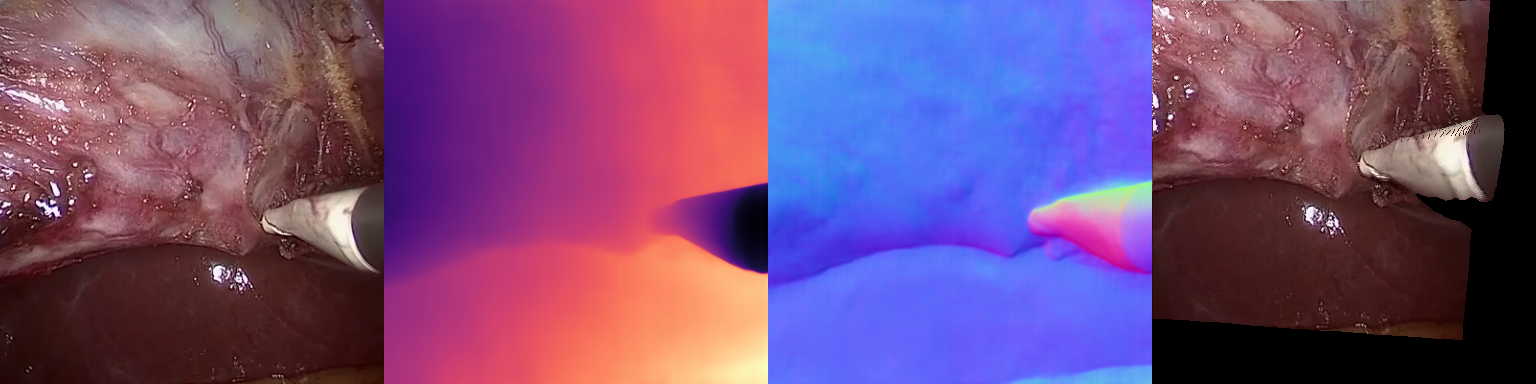

In [ ]:
import augmentations as aug
sample = next(iloader)
framestack = sample["framestack"].to(gpipe.device)
camera_pose_gt = sample["Ts2t"].to(gpipe.device)
depthstack, normals, intrinsics = gpipe.compute_geometry(framestack)
depthstack = depthstack * config.DEPTH_SCALE_FACTOR + config.DEPTH_BIAS_FACTOR
framestack, camera_pose_gt, depthstack = aug.geometric_augmentation(
    framestack,
    camera_pose_gt,
    depthstack,
    p=(
        self.config.DATASETS[
            list(self.config.DATASETS.keys())[0]
        ].AUGMENTATION_PROBABILITY["GEOMETRIC"]
    ),
    # target_only=True,
    )
(
    warped,
    source_matched_points,
    target_matched_points_true,
    embedding_mask,
) = mpipe.synthethize_ground_truth(
    framestack, intrinsics[:, 0], camera_pose_gt, depthstack[:, 0]
).values()
# rgb(
#     panelize(
#         rgb(framestack[:, 0], as_tensor=True),
#         rgb(depthstack[:, 0], as_tensor=True),
#         rgb(normals[:, 0], as_tensor=True),
#         rgb(warped, as_tensor=True),
#     )
# )

synthetic_framestack = framestack.clone()
synthetic_framestack[:, 1] = warped.clone()

descriptors = mpipe.model(synthetic_framestack)
triplets = mpipe.mine_triplets(
    descriptors,
    source_matched_points,
    target_matched_points_true,
    embedding_mask,
)
A, P, N = [triplets.get(key) for key in ["anchor", "positive", "negative"]]

loss_tensor = loss_fn(A, P, N)
loss_value = loss_tensor.detach().cpu().item()
# print(loss_value)
# rgb(
#     panelize(
#         rgb(
#             descriptors["source_embedding"].reshape(1, 1024, 48, 48).detach(),
#             as_tensor=True,
#             resize=(256, 256),
#         ),
#         rgb(
#             descriptors["target_embedding"].reshape(1, 1024, 48, 48).detach(),
#             as_tensor=True,
#             resize=(256, 256),
#         ),
#         rgb(
#             descriptors["source_embedding_match"].reshape(1, 1024, 48, 48).detach(),
#             as_tensor=True,
#             resize=(256, 256),
#         ),
#         rgb(
#             descriptors["target_embedding_match"].reshape(1, 1024, 48, 48).detach(),
#             as_tensor=True,
#             resize=(256, 256),
#         ),
#     )
# )
(
    source_pixels_matched,
    target_pixels_matched,
    batch_idx_match,
    descriptor_scores,
    refinement_scores,
    sim_matrix,
) = mpipe.compute_correspondences(
    descriptors,
    synthetic_framestack,
    embedding_mask,
).values()
fundamental_pred, inliers, epipolar_scores = mpipe.RANSAC(
    source_pixels_matched,
    target_pixels_matched,
    batch_idx_match,
).values()
scores = mpipe.combine_scores(
    descriptor_scores,
    refinement_scores,
    epipolar_scores,
    config.SCORE_WEIGHTS,
)
(
    warped,
    source_pixels_matched,
    true_pixels_matched,
    embedding_mask,
) = mpipe.synthethize_ground_truth(
    synthetic_framestack,
    intrinsics[:, 0],
    camera_pose_gt,
    depthstack[:, 0],
    source_pixels_matched,
    batch_idx_match,
).values()

batch_idx = 0
topk=40
batch_filter = batch_idx_match == batch_idx

viewComparePixelMatches(
    img1=synthetic_framestack[batch_idx, 0],
    img2=synthetic_framestack[batch_idx, 1],
    pts1=source_pixels_matched[batch_filter],
    pts2=target_pixels_matched[batch_filter],
    pts2_true=(
        true_pixels_matched[batch_filter]
        if true_pixels_matched is not None
        else target_pixels_matched[batch_filter]
    ),
    scores=scores[batch_filter],
    topk=min(topk, len(source_pixels_matched[batch_filter])),
    use_actual_topk=True,
)